# 🧠 Parkinson's Disease Prediction Model
### Training Notebook — generates `saved_models/parkinsons_model.pkl`
**Algorithm:** Support Vector Machine (SVM) with linear kernel  
**Dataset:** UCI Parkinson's Telemonitoring Dataset (195 samples, 22 vocal features)  
**Target:** `status` — 0 = Healthy, 1 = Parkinson's Positive

> Features are biomedical voice measurements extracted from sustained phonation recordings.

## 1. Install & Import Dependencies

In [1]:
# Install required libraries (run once)
# !pip install numpy pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import svm
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 2. Load & Explore the Dataset

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Place parkinsons.csv in the same folder as this notebook
df = pd.read_csv('parkinsons.csv')

print("Shape:", df.shape)
print("\nColumns (24 total — 'name' and 'status' excluded from features):")
print(list(df.columns))

Shape: (195, 24)

Columns (24 total — 'name' and 'status' excluded from features):
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [3]:
print("\nFirst 5 rows (key columns):")
df[['name','MDVP:Fo(Hz)','MDVP:Jitter(%)','MDVP:Shimmer','HNR','status']].head()


First 5 rows (key columns):


,name,MDVP:Fo(Hz),MDVP:Jitter(%),MDVP:Shimmer,HNR,status
0,phon_R01_S01_1,119.992,0.00784,0.04374,21.033,1
1,phon_R01_S01_2,122.400,0.00968,0.06134,19.085,1
2,phon_R01_S01_3,116.682,0.01050,0.05233,20.651,1
3,phon_R01_S01_4,116.676,0.00997,0.05492,20.644,1
4,phon_R01_S01_5,116.014,0.01284,0.06425,19.649,1


In [4]:
print("Dataset Statistics (numeric columns):")
df.describe().round(4)

Dataset Statistics (numeric columns):


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,...,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000,195.0000
mean,154.2286,197.1049,116.3246,0.0062,0.0000,0.0033,0.0034,0.0099,0.0297,0.2823,...,0.0470,0.0248,21.8860,0.7538,0.4985,0.7181,-5.6844,0.2265,2.3818,0.2066
std,41.3901,91.4915,43.5214,0.0048,0.0000,0.0030,0.0028,0.0089,0.0189,0.1949,...,0.0305,0.0404,4.4258,0.4319,0.1039,0.0553,1.0902,0.0834,0.3828,0.0901
min,88.3330,102.1450,65.4760,0.0017,0.0000,0.0007,0.0009,0.0020,0.0095,0.0850,...,0.0136,0.0006,8.4410,0.0000,0.2566,0.5743,-7.9650,0.0063,1.4233,0.0445
25%,117.5720,134.8625,84.2910,0.0035,0.0000,0.0017,0.0019,0.0050,0.0165,0.1485,...,0.0247,0.0059,19.1980,1.0000,0.4213,0.6748,-6.4501,0.1744,2.0991,0.1375
50%,148.7900,175.8290,104.3150,0.0049,0.0000,0.0025,0.0027,0.0075,0.0230,0.2210,...,0.0384,0.0117,22.0850,1.0000,0.4960,0.7223,-5.7209,0.2189,2.3615,0.1941
75%,182.7690,224.2055,140.0185,0.0074,0.0001,0.0038,0.0040,0.0115,0.0379,0.3500,...,0.0608,0.0256,25.0755,1.0000,0.5876,0.7619,-5.0462,0.2792,2.6365,0.2530
max,260.1050,592.0300,239.1700,0.0332,0.0003,0.0214,0.0196,0.0643,0.1191,1.3020,...,0.1694,0.3148,33.0470,1.0000,0.6852,0.8253,-2.4340,0.4505,3.6712,0.5274


Class Distribution (status):
status
1    147
0     48
Name: count, dtype: int64

  0 = Healthy              : 48 samples
  1 = Parkinson's Positive : 147 samples


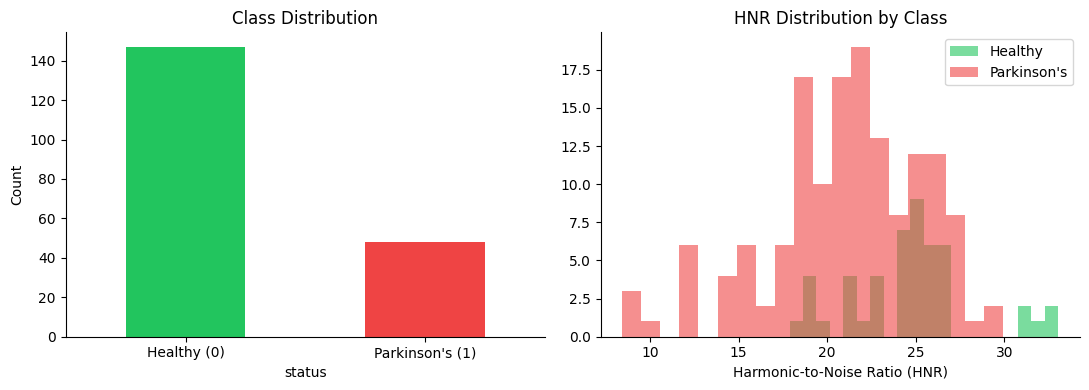

In [5]:
# Class distribution
print("Class Distribution (status):")
print(df['status'].value_counts())
print(f"\n  0 = Healthy              : {(df['status']==0).sum()} samples")
print(f"  1 = Parkinson's Positive : {(df['status']==1).sum()} samples")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Class balance
df['status'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#22c55e','#ef4444'], edgecolor='none')
axes[0].set_xticklabels(['Healthy (0)', "Parkinson's (1)"], rotation=0)
axes[0].set_title('Class Distribution', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].spines[['top','right']].set_visible(False)

# HNR (Harmonic-to-Noise Ratio) by class — strong discriminator
for label, color, name in zip([0,1], ['#22c55e','#ef4444'], ['Healthy',"Parkinson's"]):
    axes[1].hist(df[df['status']==label]['HNR'], bins=20, alpha=0.6,
                 color=color, label=name)
axes[1].set_title('HNR Distribution by Class', fontsize=12)
axes[1].set_xlabel('Harmonic-to-Noise Ratio (HNR)')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Check for Missing Values

In [6]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete ✓")

Missing values per column:
None — dataset is complete ✓


## 4. Feature Distributions by Class

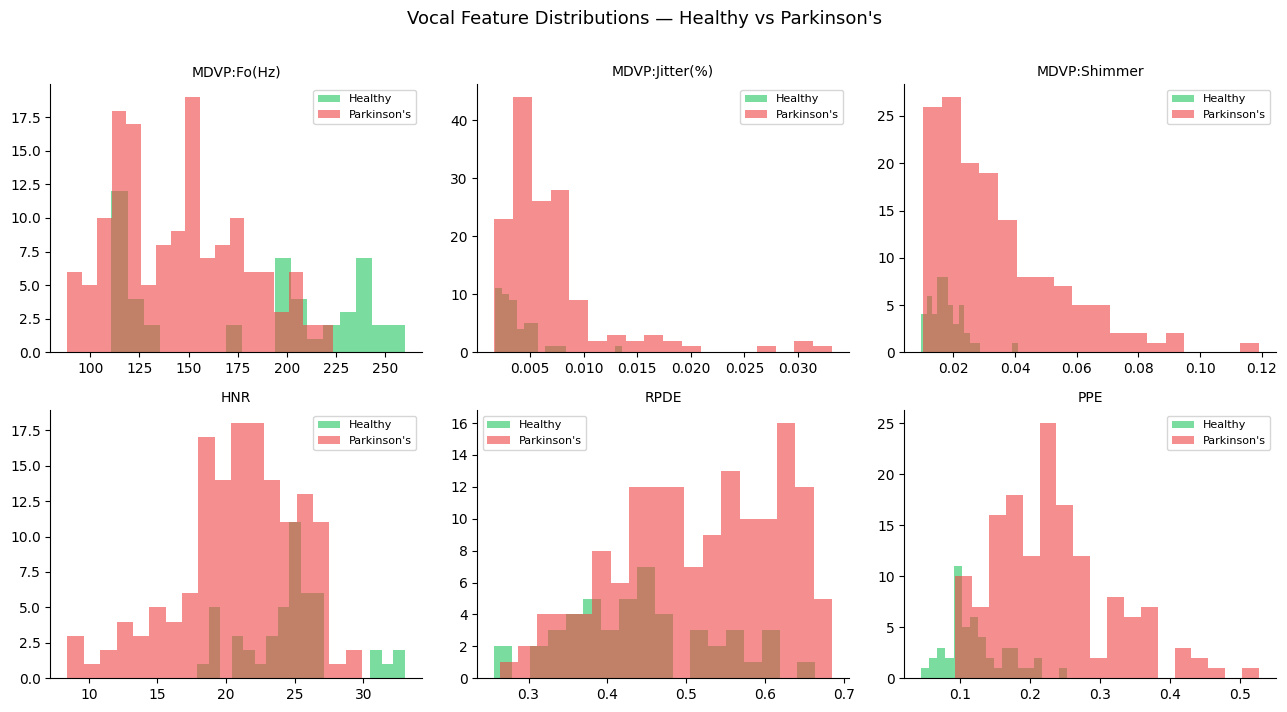

In [7]:
# Show top 6 most discriminating vocal features
key_features = ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer',
                'HNR', 'RPDE', 'PPE']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label, color, name in zip([0,1], ['#22c55e','#ef4444'],
                                   ['Healthy',"Parkinson's"]):
        axes[i].hist(df[df['status']==label][feat], bins=18,
                     alpha=0.6, color=color, label=name)
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].spines[['top','right']].set_visible(False)

fig.suptitle('Vocal Feature Distributions — Healthy vs Parkinson\'s',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation Heatmap (Key Features)

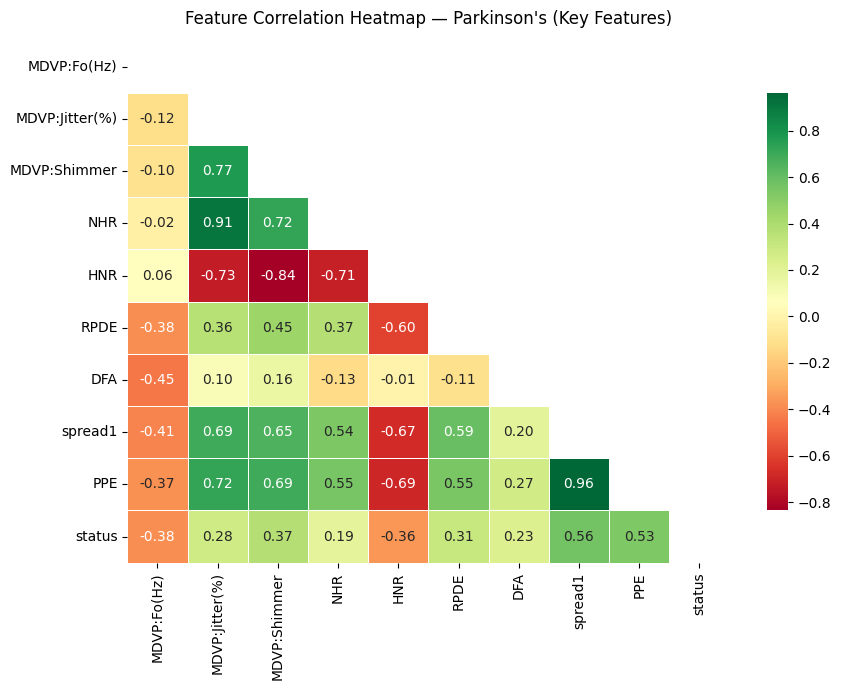

In [8]:
key_cols = ['MDVP:Fo(Hz)','MDVP:Jitter(%)','MDVP:Shimmer',
            'NHR','HNR','RPDE','DFA','spread1','PPE','status']
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df[key_cols].corr(), dtype=bool))
sns.heatmap(df[key_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={'shrink':0.8})
ax.set_title("Feature Correlation Heatmap — Parkinson's (Key Features)",
             fontsize=12, pad=12)
plt.tight_layout()
plt.show()

## 6. Prepare Features & Labels

In [9]:
# Drop 'name' (identifier) and 'status' (target label)
X = df.drop(columns=['name', 'status'])
Y = df['status']

print("Feature columns (22):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")
print(f"\nFeature matrix : {X.shape}")
print(f"Label vector   : {Y.shape}")

Feature columns (22):
   1. MDVP:Fo(Hz)
   2. MDVP:Fhi(Hz)
   3. MDVP:Flo(Hz)
   4. MDVP:Jitter(%)
   5. MDVP:Jitter(Abs)
   6. MDVP:RAP
   7. MDVP:PPQ
   8. Jitter:DDP
   9. MDVP:Shimmer
  10. MDVP:Shimmer(dB)
  11. Shimmer:APQ3
  12. Shimmer:APQ5
  13. MDVP:APQ
  14. Shimmer:DDA
  15. NHR
  16. HNR
  17. RPDE
  18. DFA
  19. spread1
  20. spread2
  21. D2
  22. PPE

Feature matrix : (195, 22)
Label vector   : (195,)


## 7. Train / Test Split

In [10]:
# 80/20 split — no stratify (small dataset, repo uses random_state=2)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class balance: {dict(Y_train.value_counts())}")
print(f"Test  class balance: {dict(Y_test.value_counts())}")

Training set : 156 samples
Test set     : 39 samples

Train class balance: {1: 116, 0: 40}
Test  class balance: {1: 31, 0: 8}


## 8. Train the SVM Model

In [11]:
model = svm.SVC(kernel='linear', random_state=2)
model.fit(X_train, Y_train)

print("✅ Model training complete!")
print(f"   Model type : {type(model).__name__}")
print(f"   Kernel     : {model.kernel}")
print(f"   C (reg.)   : {model.C}")

✅ Model training complete!
   Model type : SVC
   Kernel     : linear
   C (reg.)   : 1.0


## 9. Model Evaluation

In [12]:
train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

train_acc = accuracy_score(Y_train, train_pred)
test_acc  = accuracy_score(Y_test,  test_pred)

print("=" * 45)
print("        MODEL ACCURACY REPORT")
print("=" * 45)
print(f"  Training Accuracy : {train_acc*100:.2f}%")
print(f"  Test     Accuracy : {test_acc*100:.2f}%")
print("=" * 45)

        MODEL ACCURACY REPORT
  Training Accuracy : 87.18%
  Test     Accuracy : 87.18%


In [13]:
print("\nClassification Report (Test Set):\n")
print(classification_report(Y_test, test_pred,
      target_names=['Healthy', "Parkinson's"]))


Classification Report (Test Set):

              precision    recall  f1-score   support

     Healthy       0.80      0.50      0.62         8
 Parkinson's       0.88      0.97      0.92        31

    accuracy                           0.87        39
   macro avg       0.84      0.73      0.77        39
weighted avg       0.87      0.87      0.86        39



In [14]:
cv_scores = cross_val_score(model, X, Y, cv=5, scoring='accuracy')
print(f"5-Fold CV Scores   : {[round(s*100,2) for s in cv_scores]}")
print(f"CV Mean Accuracy   : {cv_scores.mean()*100:.2f}%")
print(f"CV Std Deviation   : ±{cv_scores.std()*100:.2f}%")

5-Fold CV Scores   : [92.31, 82.05, 87.18, 76.92, 74.36]
CV Mean Accuracy   : 82.56%
CV Std Deviation   : ±6.57%


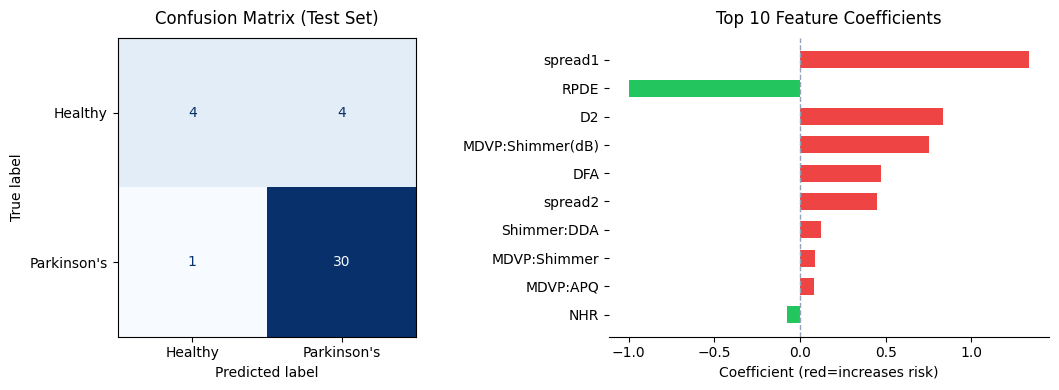


  True  Positives (Parkinson's correctly identified)  : 30
  True  Negatives (Healthy correctly identified)      : 4
  False Positives (Healthy flagged as Parkinson's)    : 4
  False Negatives (Parkinson's missed by model)       : 1


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion Matrix
cm = confusion_matrix(Y_test, test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Parkinson's"])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix (Test Set)", pad=10)

# Feature importance via SVM coefficients
feature_names = list(X.columns)
coefs = model.coef_[0]
imp_df = pd.DataFrame({'Feature': feature_names, 'Coef': coefs,
                        'Abs': np.abs(coefs)}).nlargest(10, 'Abs').sort_values('Abs')

colors = ['#ef4444' if c > 0 else '#22c55e' for c in imp_df['Coef']]
axes[1].barh(imp_df['Feature'], imp_df['Coef'], color=colors, edgecolor='none', height=0.6)
axes[1].axvline(0, color='#94a3b8', lw=1, linestyle='--')
axes[1].set_title("Top 10 Feature Coefficients", pad=10)
axes[1].set_xlabel('Coefficient (red=increases risk)')
axes[1].spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n  True  Positives (Parkinson's correctly identified)  : {tp}")
print(f"  True  Negatives (Healthy correctly identified)      : {tn}")
print(f"  False Positives (Healthy flagged as Parkinson's)    : {fp}")
print(f"  False Negatives (Parkinson's missed by model)       : {fn}")

## 10. Sample Prediction

In [20]:
# Healthy voice sample from the original repo notebook
sample = np.array([[197.076, 206.896, 192.055, 0.00289, 0.00001, 0.00166,
                    0.00168, 0.00498, 0.01098, 0.097,   0.00563, 0.00680,
                    0.00802, 0.01689, 0.00339, 26.775,  0.422229,0.741367,
                    -7.3483, 0.177551,1.743867,0.085569]])

result = model.predict(sample)
feature_names = list(X.columns)
print("Sample input (key features):")
for feat, val in zip(feature_names[:6], sample[0][:6]):
    print(f"  {feat}: {val}")
print("  ...")
if result[0] == 1:
    prediction_text = "🔴 PARKINSON'S"
else:
    prediction_text = "🟢 HEALTHY (No Parkinson's)"

print(f"\nPrediction : {prediction_text}")
print(f"Expected   : 🟢 HEALTHY  (confirmed from notebook)")

Sample input (key features):
  MDVP:Fo(Hz): 197.076
  MDVP:Fhi(Hz): 206.896
  MDVP:Flo(Hz): 192.055
  MDVP:Jitter(%): 0.00289
  MDVP:Jitter(Abs): 1e-05
  MDVP:RAP: 0.00166
  ...

Prediction : 🟢 HEALTHY (No Parkinson's)
Expected   : 🟢 HEALTHY  (confirmed from notebook)


## 11. Save Model as `.pkl`

In [21]:
os.makedirs('saved_models', exist_ok=True)

model_path = 'saved_models/parkinsons_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

verify_acc = accuracy_score(Y_test, loaded_model.predict(X_test))

print("=" * 45)
print("  ✅  MODEL SAVED SUCCESSFULLY")
print("=" * 45)
print(f"  File        : {model_path}")
print(f"  Size        : {os.path.getsize(model_path):,} bytes")
print(f"  Verify acc  : {verify_acc*100:.2f}%  (matches original ✓)")
print()
print("  → Place 'saved_models/parkinsons_model.pkl'")
print("    inside your project's saved_models/ folder")
print("    then run:  streamlit run app.py")

  ✅  MODEL SAVED SUCCESSFULLY
  File        : saved_models/parkinsons_model.pkl
  Size        : 12,388 bytes
  Verify acc  : 87.18%  (matches original ✓)

  → Place 'saved_models/parkinsons_model.pkl'
    inside your project's saved_models/ folder
    then run:  streamlit run app.py
